In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
subset_features = pd.read_csv('./subset_chem_phys_features.txt', sep='\t', index_col=0)

In [8]:
subset_features.reset_index(inplace=True)
subset_features.rename(columns={'ID': 'protein'}, inplace=True)
subset_features.set_index(['index', 'protein'], inplace=True)

In [32]:
subset_features.reset_index()

,index,protein,Normalized Hydrophobic Moment,Normalized Hydrophobicity,Net Charge,Isoelectric Point,Penetration Depth,Tilt Angle,Disordered Conformation Propensity,Linear Moment,Propensity to in vitro Aggregation,Angle Subtended by the Hydrophobic Residues,Amphiphilicity Index,Propensity to PPII coil
0,8,KVvvKWVvKvVK,1.97,-1.07,5.0,14.00,10,87,0.24,0.26,0.00,190.0,1.80,0.98
1,10,LFIFFF,0.41,-3.25,1.0,14.00,0,62,1.25,0.00,500.03,360.0,0.00,0.96
2,11,RVKRVWPLVIRTVIAGYNLY,1.08,0.07,8.0,11.79,13,86,-0.09,0.28,18.63,30.0,1.60,1.01
3,12,RKRIHIGPGRAFYTT,0.46,0.81,4.0,11.85,22,172,-0.27,0.39,0.00,50.0,1.17,1.02
4,14,GIWDTIKSMGKVFAGKILQN,1.01,-0.29,3.0,10.99,15,88,0.23,0.20,0.61,70.0,0.91,0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,4348,FSFKRLKGFAKKLWNSKLAR,0.56,0.73,7.0,10.69,30,63,-0.11,0.07,0.00,20.0,1.14,1.03
3697,4349,GLRSKIWLWVLLMIWQESNK,0.65,0.01,4.0,11.11,14,79,0.07,0.40,986.05,50.0,1.68,0.95
3698,4350,RSGRGECRRQCLRRHEGQPW,0.64,2.03,7.0,11.45,30,93,-0.60,0.24,0.00,20.0,1.34,0.99
3699,4351,QGVRNSQSCRRNKGICVPIR,0.62,0.57,10.0,11.17,30,86,-0.17,0.27,0.00,30.0,0.79,1.04


In [54]:
censored = subset_features.copy()
censored_vars = {}
discrete_vars = []
for col in subset_features.columns:
    print(col)
    data = subset_features[col]
    print('# Null:', data.isnull().sum())
    data = data[data.notnull()]
    discrete = np.all(data == data.astype(int))
    print('Discrete:', discrete)
    if discrete:
        discrete_vars.append(col)
    num_in_mode = int(sum(data.values == data.mode().values))
    mode = data.mode().values[0]

    if num_in_mode > 400 and (mode == data.min() or mode == data.max()):
        print('Mode:', data.mode().values[0])
        print('# in Mode:', num_in_mode)
        print('Min, max:', data.min(), data.max())
        mask = censored[col] == mode
        censored.loc[mask, col] = None
        censored_vars[col] = (mode, 'min' if mode == data.min() else 'max')

    print('-----------------------')


Normalized Hydrophobic Moment
# Null: 0
Discrete: False
-----------------------
Normalized Hydrophobicity
# Null: 0
Discrete: False
-----------------------
Net Charge
# Null: 1
Discrete: True
-----------------------
Isoelectric Point
# Null: 0
Discrete: False
Mode: 14.0
# in Mode: 961
Min, max: 2.49 14.0
-----------------------
Penetration Depth
# Null: 0
Discrete: True
Mode: 30
# in Mode: 569
Min, max: 0 30
-----------------------
Tilt Angle
# Null: 0
Discrete: True
-----------------------
Disordered Conformation Propensity
# Null: 0
Discrete: False
-----------------------
Linear Moment
# Null: 0
Discrete: False
-----------------------
Propensity to in vitro Aggregation
# Null: 0
Discrete: False
Mode: 0.0
# in Mode: 1985
Min, max: 0.0 1425.13
-----------------------
Angle Subtended by the Hydrophobic Residues
# Null: 0
Discrete: True
-----------------------
Amphiphilicity Index
# Null: 0
Discrete: False
-----------------------
Propensity to PPII coil
# Null: 0
Discrete: False
--------

In [56]:
discrete_vars

['Net Charge',
 'Penetration Depth',
 'Tilt Angle',
 'Angle Subtended by the Hydrophobic Residues']

In [40]:
censored.reset_index()

,index,protein,Normalized Hydrophobic Moment,Normalized Hydrophobicity,Net Charge,Isoelectric Point,Penetration Depth,Tilt Angle,Disordered Conformation Propensity,Linear Moment,Propensity to in vitro Aggregation,Angle Subtended by the Hydrophobic Residues,Amphiphilicity Index,Propensity to PPII coil
0,8,KVvvKWVvKvVK,1.97,-1.07,5.0,NaN,10.0,87,0.24,0.26,NaN,190.0,1.80,0.98
1,10,LFIFFF,0.41,-3.25,1.0,NaN,0.0,62,1.25,0.00,500.03,360.0,0.00,0.96
2,11,RVKRVWPLVIRTVIAGYNLY,1.08,0.07,8.0,11.79,13.0,86,-0.09,0.28,18.63,30.0,1.60,1.01
3,12,RKRIHIGPGRAFYTT,0.46,0.81,4.0,11.85,22.0,172,-0.27,0.39,NaN,50.0,1.17,1.02
4,14,GIWDTIKSMGKVFAGKILQN,1.01,-0.29,3.0,10.99,15.0,88,0.23,0.20,0.61,70.0,0.91,0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3696,4348,FSFKRLKGFAKKLWNSKLAR,0.56,0.73,7.0,10.69,NaN,63,-0.11,0.07,NaN,20.0,1.14,1.03
3697,4349,GLRSKIWLWVLLMIWQESNK,0.65,0.01,4.0,11.11,14.0,79,0.07,0.40,986.05,50.0,1.68,0.95
3698,4350,RSGRGECRRQCLRRHEGQPW,0.64,2.03,7.0,11.45,NaN,93,-0.60,0.24,NaN,20.0,1.34,0.99
3699,4351,QGVRNSQSCRRNKGICVPIR,0.62,0.57,10.0,11.17,NaN,86,-0.17,0.27,NaN,30.0,0.79,1.04


In [48]:
censored.loc[(slice(None), 'GILDTLKQFAKGVGKDLVKG'),:]

,,Normalized Hydrophobic Moment,Normalized Hydrophobicity,Net Charge,Isoelectric Point,Penetration Depth,Tilt Angle,Disordered Conformation Propensity,Linear Moment,Propensity to in vitro Aggregation,Angle Subtended by the Hydrophobic Residues,Amphiphilicity Index,Propensity to PPII coil
index,protein,,,,,,,,,,,,
916,GILDTLKQFAKGVGKDLVKG,0.52,-0.33,4.0,10.09,NaN,48,0.24,0.17,22.41,30.0,0.66,0.90
3082,GILDTLKQFAKGVGKDLVKG,0.99,-0.34,2.0,10.28,24.0,58,0.28,0.22,26.23,30.0,0.57,0.87
3083,GILDTLKQFAKGVGKDLVKG,1.00,-0.38,2.0,10.28,14.0,102,0.29,0.24,NaN,30.0,0.59,0.86
3084,GILDTLKQFAKGVGKDLVKG,1.10,-0.24,2.0,10.28,23.0,58,0.24,0.21,NaN,30.0,0.61,0.85
3085,GILDTLKQFAKGVGKDLVKG,1.16,-0.27,2.0,10.28,23.0,57,0.25,0.22,NaN,70.0,0.64,0.85
3086,GILDTLKQFAKGVGKDLVKG,1.21,-0.32,2.0,10.28,22.0,59,0.26,0.23,NaN,70.0,0.66,0.83
3087,GILDTLKQFAKGVGKDLVKG,1.41,-0.18,2.0,10.28,22.0,58,0.22,0.21,NaN,70.0,0.69,0.83
3088,GILDTLKQFAKGVGKDLVKG,1.45,-0.01,2.0,10.28,22.0,56,0.16,0.18,NaN,70.0,0.72,0.82


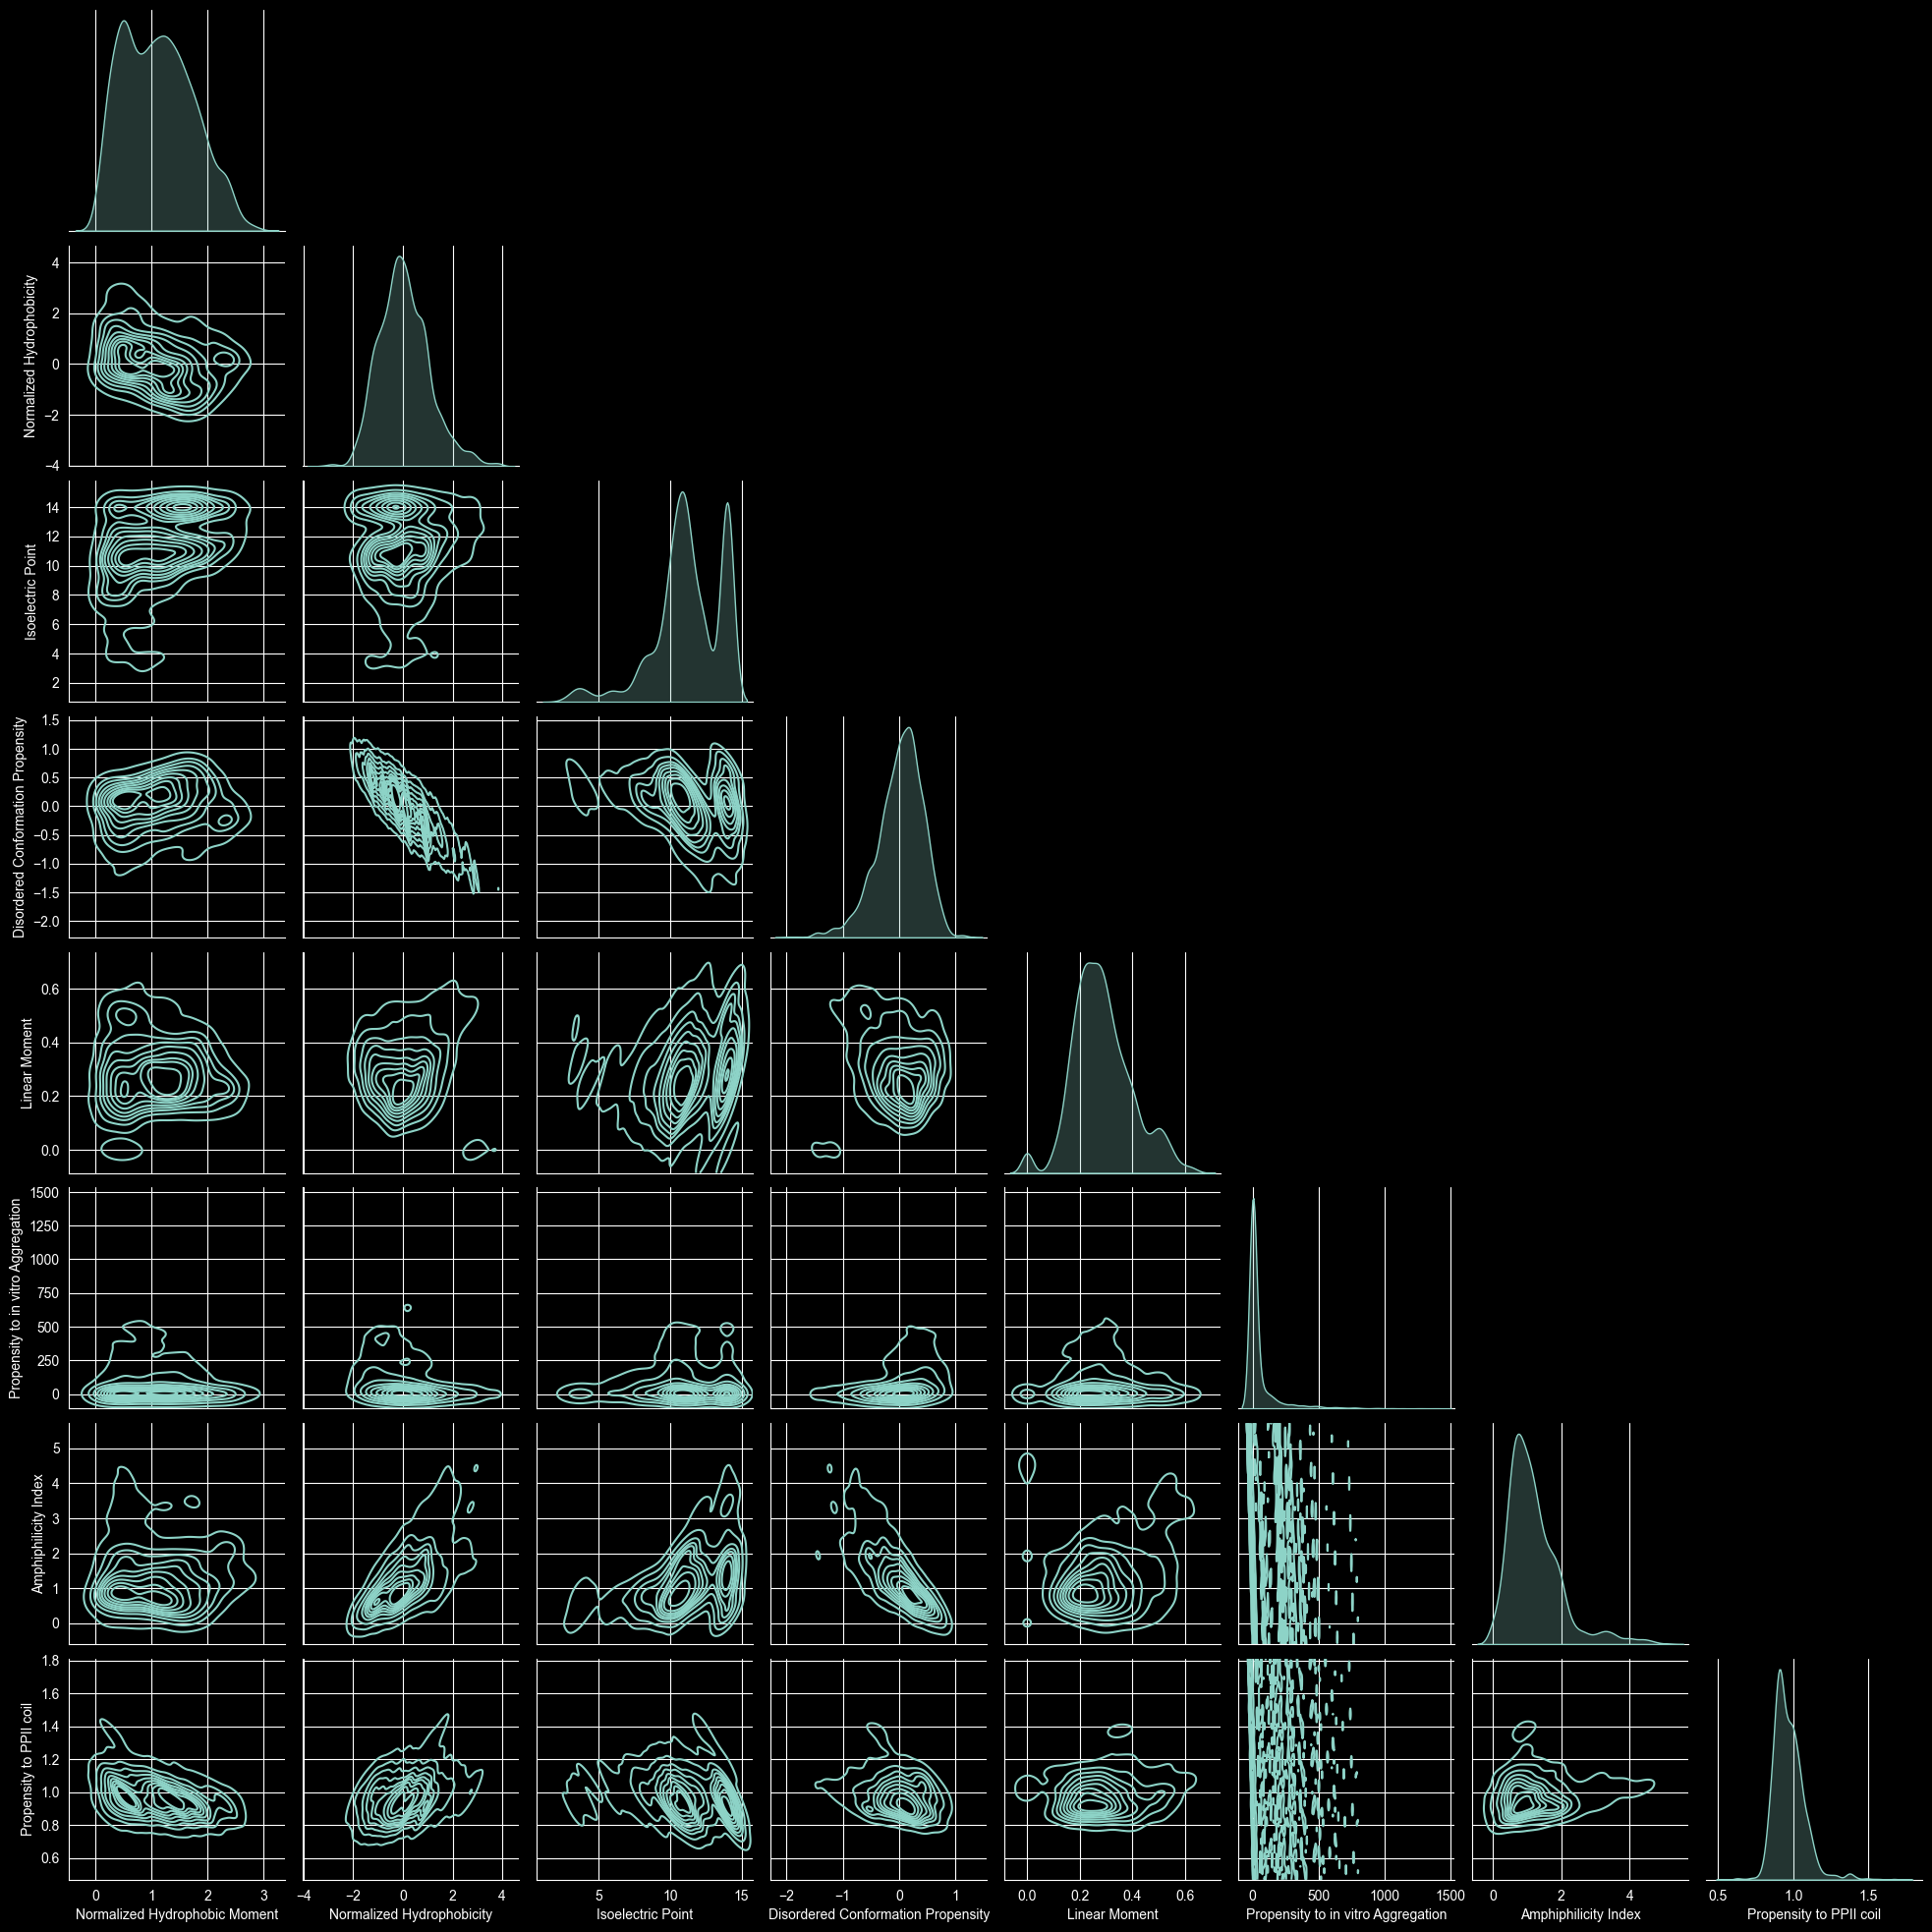

In [66]:
sns.pairplot(subset_features[[v for v in subset_features.columns if v not in discrete_vars]]
, kind='kde', corner=True)

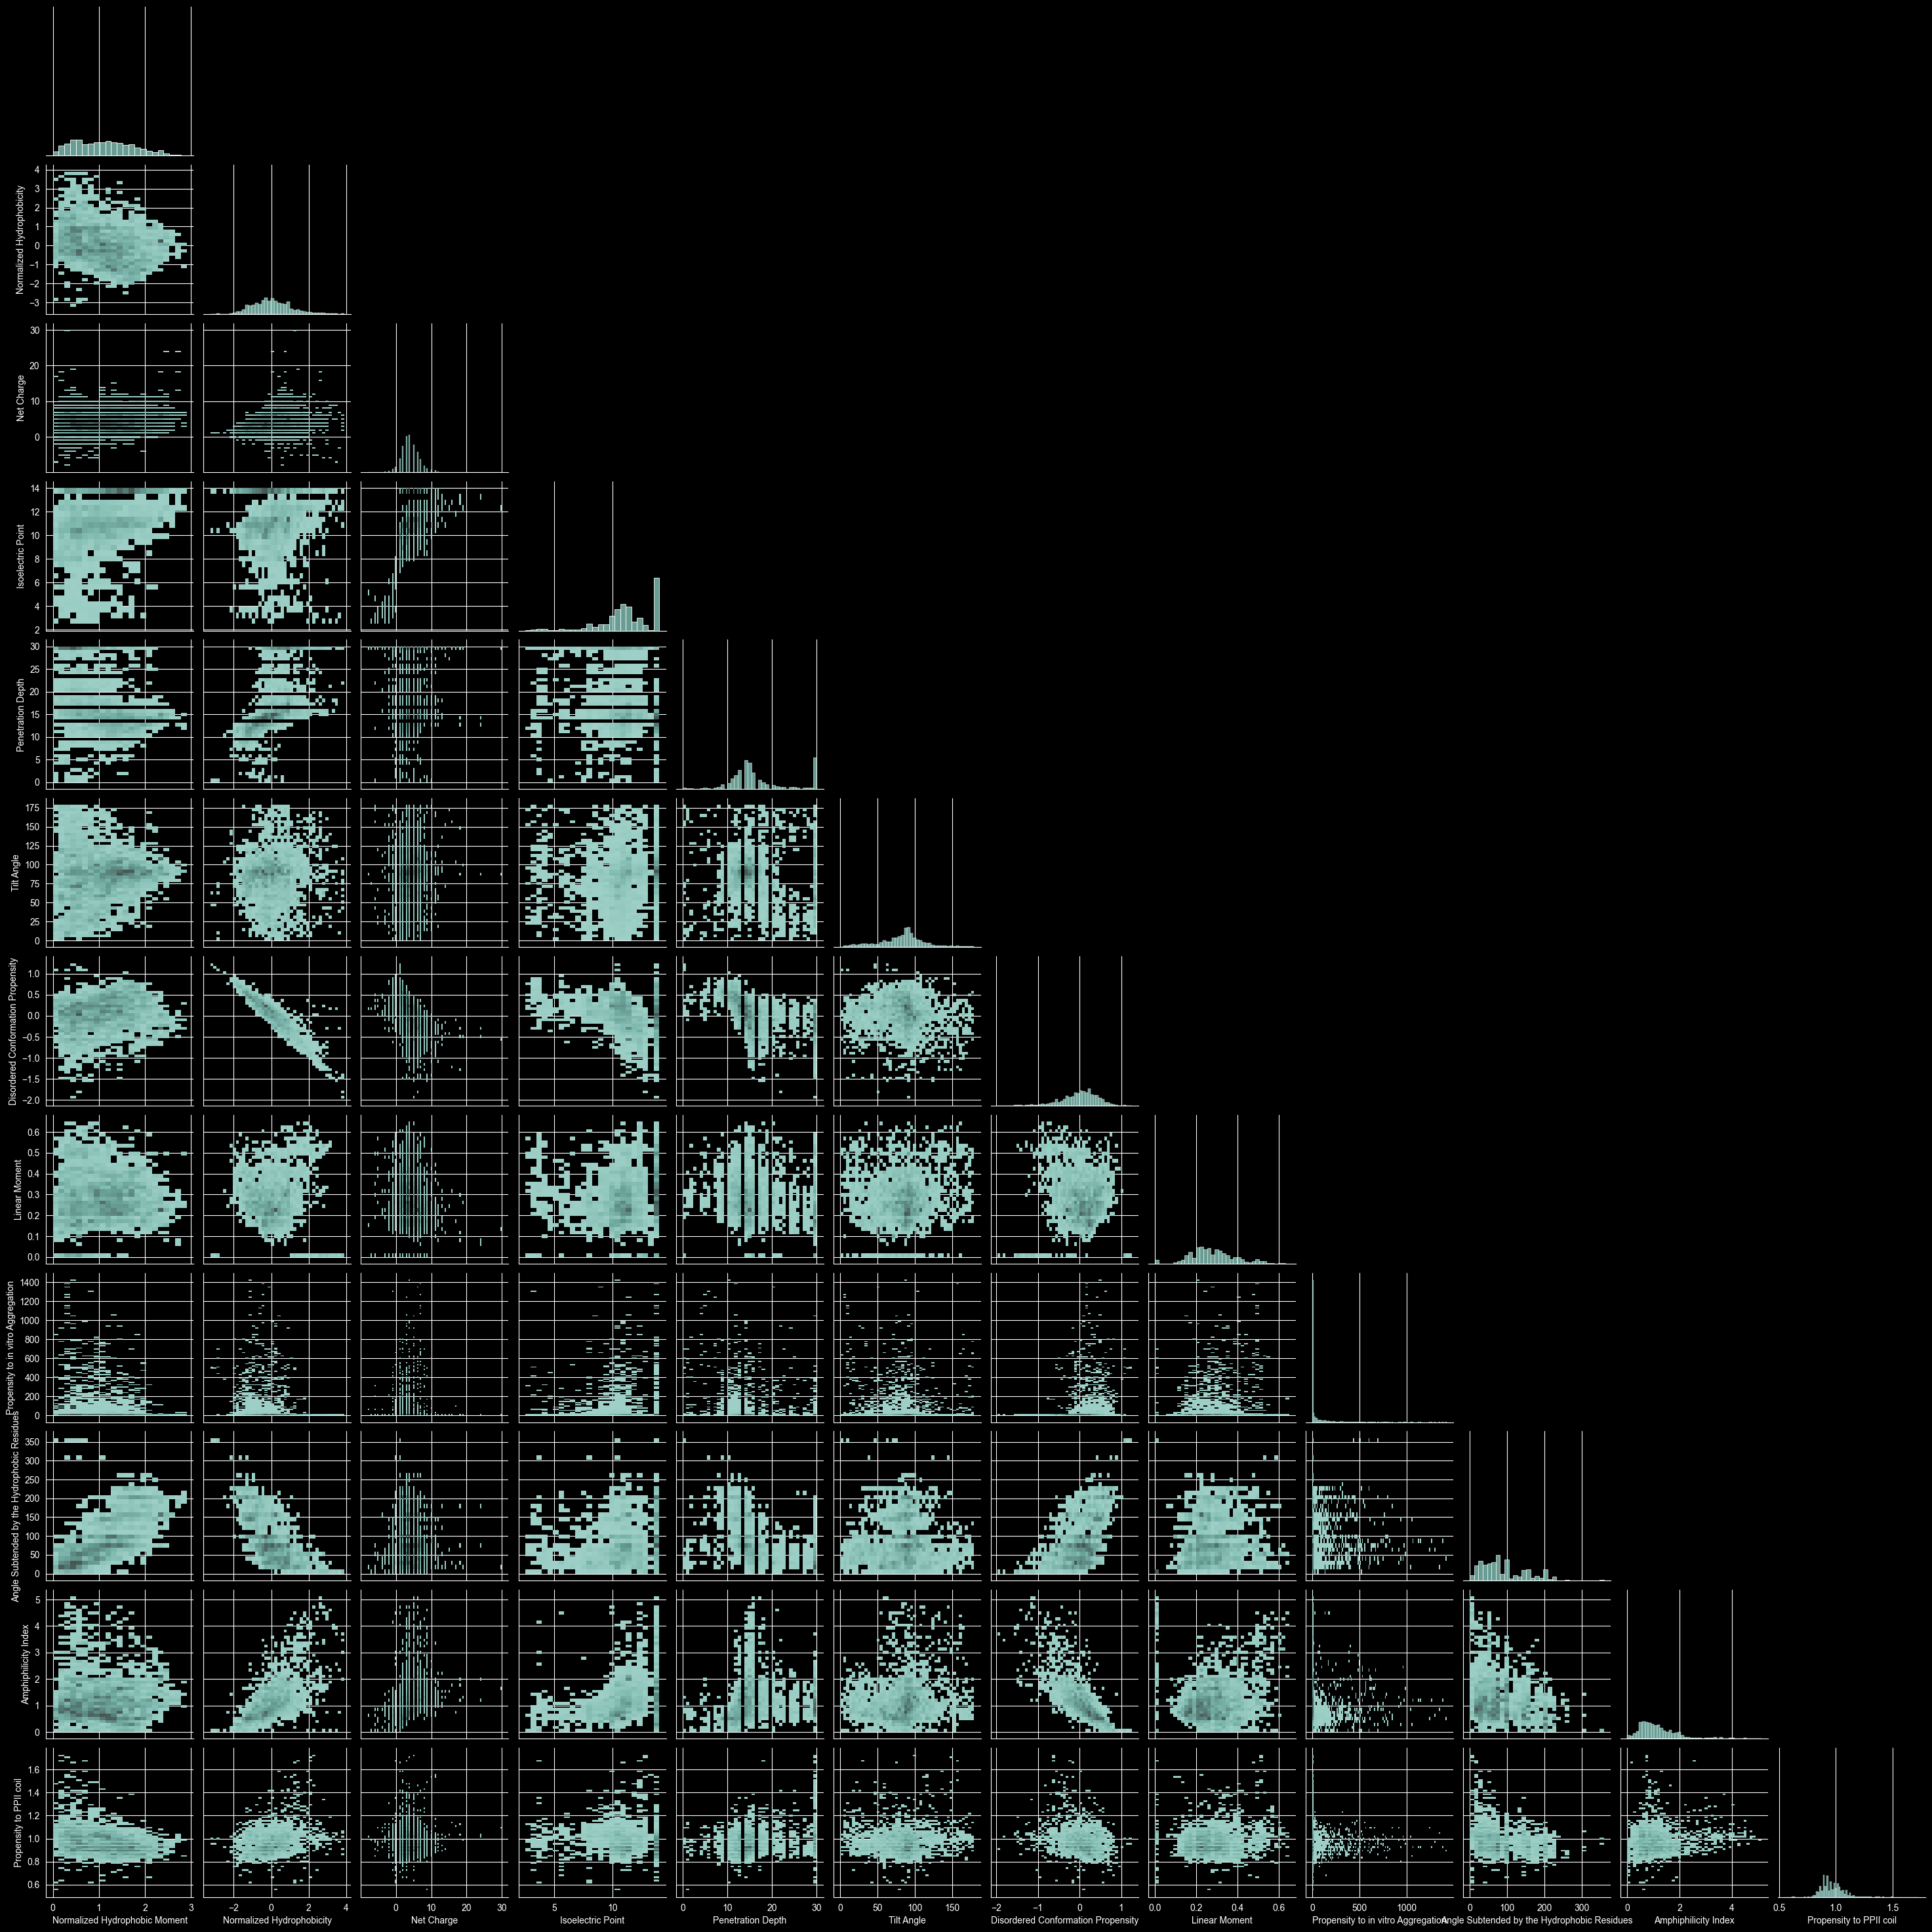

In [67]:
sns.pairplot(subset_features
, kind='hist', corner=True)

In [71]:
# "Anomalies"
# The missing/thresholded values for three variables
# Unclear if propensity is censored or just strongly skewed?
censored_vars

{'Isoelectric Point': (np.float64(14.0), 'max'),
 'Penetration Depth': (np.int64(30), 'max'),
 'Propensity to in vitro Aggregation': (np.float64(0.0), 'min')}

In [73]:
# Discrete variables
discrete_vars

['Net Charge',
 'Penetration Depth',
 'Tilt Angle',
 'Angle Subtended by the Hydrophobic Residues']

## "Distributions"
- Some are relatively normal, but some are skewed/overly dispersed
- Disoriented Conformation Propensity strongly correlated with Normalized Hydrophobicity
    - weaker (neg) correlation with Amphilicity Index
- all others not very correlated
- Isoelectric point is bimodal

In [ ]:
# PCA on feature set